# ECG - MIT-BIH Arrhythmia   
**Authors**: Nevo Levi, Roten Even Zur, Guy Kalati   **Date**: <today>

## 0. Environment & Package Setup

In [ ]:
!pip -q install imbalanced-learn==0.12 seaborn==0.13 tf-keras-vis==0.8

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
sns.set_style("whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ERROR: Ignored the following versions that require a different python version: 0.2.0 Requires-Python >=3.5, <3.8; 0.2.1 Requires-Python >=3.5, <3.8; 0.2.3 Requires-Python >=3.5, <3.8; 0.2.4 Requires-Python >=3.5, <=3.8; 0.2.5 Requires-Python >=3.5, <3.9; 0.3.1 Requires-Python >=3.5, <3.9; 0.3.2 Requires-Python >=3.5, <3.9; 0.3.3 Requires-Python >=3.5, <3.9; 0.4.0 Requires-Python >=3.5, <3.9; 0.5.0 Requires-Python >=3.5, <3.9; 0.5.2 Requires-Python >=3.5, <3.9; 0.5.3 Requires-Python >=3.5, <3.9; 0.5.4 Requires-Python >=3.5, <3.9; 0.5.5 Requires-Python >=3.6, <3.9; 0.6.0 Requires-Python >=3.6, <3.10; 0.6.1 Requires-Python >=3.6, <3.10; 0.6.2 Requires-Python >=3.6, <3.10; 0.7.0 Requires-Python >=3.6, <3.10; 0.7.1 Requires-Python >=3.6, <3.10; 0.7.2 Requires-Python >=3.6, <3.10; 0.8.0 Requires-Python >=3.6, <3.10; 0.8.1 Requires-Python >=3.7, <3.11
ERROR: Could not find a version that satisfies the requirement tf-keras-vis==0.8 (from versions: 0.0.1, 0.1.0, 0.8.2, 0.8.3, 0.8.4, 0.8.5, 0.8.

## 1. Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH    = '/content/drive/MyDrive'
TRAIN_PATH   = f'{BASE_PATH}/mitbih_train.csv'
TEST_PATH    = f'{BASE_PATH}/mitbih_test.csv'

In [ ]:

train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)

print(f"Train shape: {train_df.shape}  |  Test shape: {test_df.shape}")


Train shape: (87554, 188)  |  Test shape: (21892, 188)


## 2. EDA

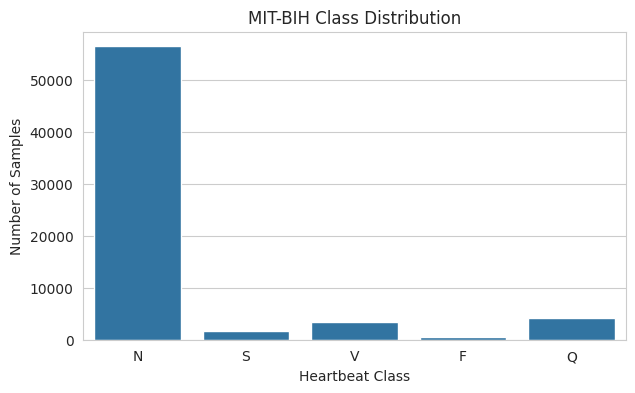

In [ ]:
class_names = {0:"N",1:"S",2:"V",3:"F",4:"Q"}
label_col   = 187

# Map int codes → strings, keep for plotting & CNN later
train_df[label_col] = pd.to_numeric(train_df[label_col], errors="coerce").astype(int)
train_df["label_str"] = train_df[label_col].map(class_names)
train_df["label_str"] = pd.Categorical(
    train_df["label_str"],
    categories=list(class_names.values()),
    ordered=True
)

# Plot class counts
plt.figure(figsize=(7,4))
sns.countplot(
    x="label_str",
    data=train_df,
    order=list(class_names.values())
)
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")
plt.title("MIT-BIH Class Distribution")
plt.show()

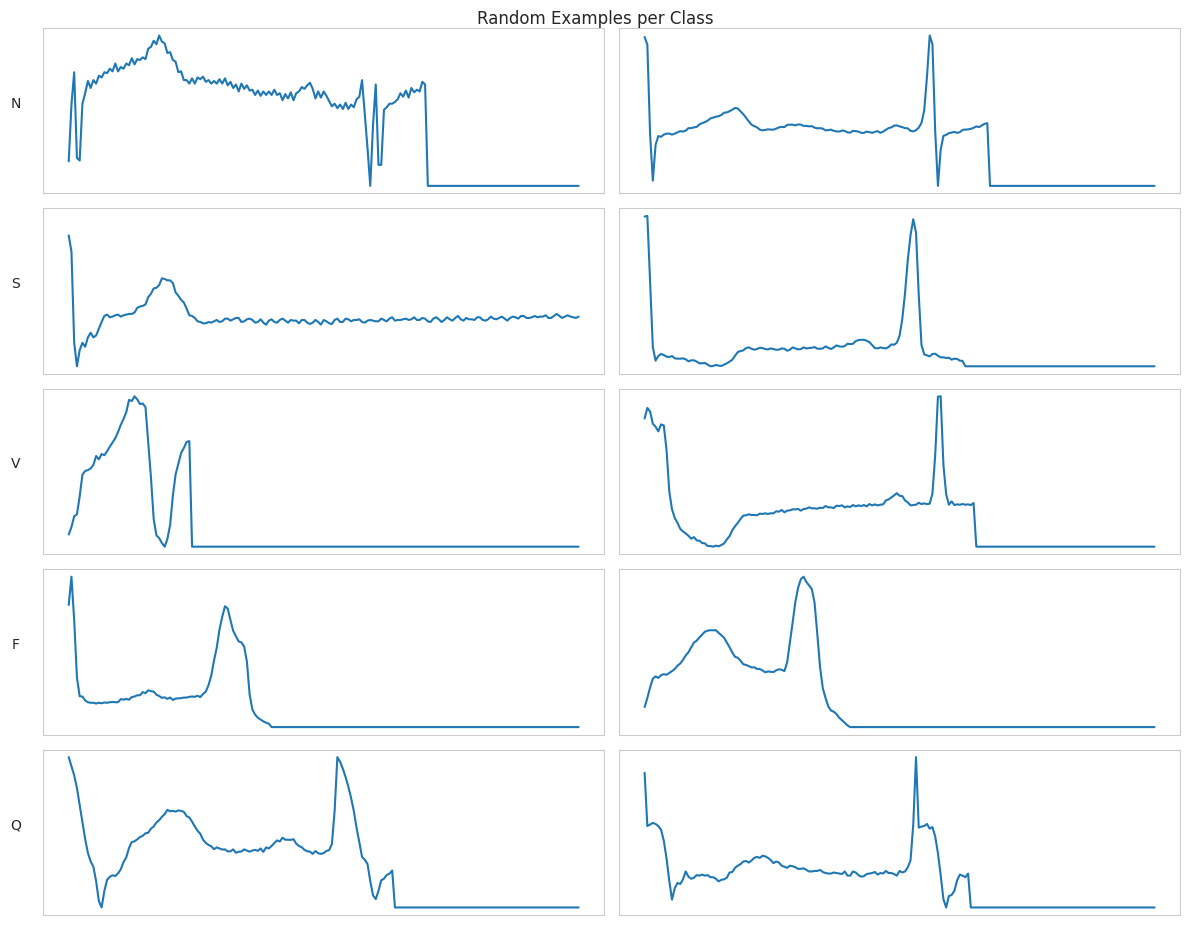

In [ ]:
def plot_examples(df, n_per_class=2):
    fig, axs = plt.subplots(
        nrows=len(class_names),
        ncols=n_per_class,
        figsize=(12,10),
        sharex=True, sharey=True
    )
    for row,(code,lab) in enumerate(class_names.items()):
        subset = df[df["label_str"]==lab]
        samples = subset.sample(n_per_class, random_state=SEED).iloc[:,:187].values
        for col in range(n_per_class):
            axs[row,col].plot(samples[col])
            axs[row,col].set_xticks([]); axs[row,col].set_yticks([])
            if col==0:
                axs[row,col].set_ylabel(lab, rotation=0, labelpad=20)
    fig.suptitle("Random Examples per Class", y=0.92)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_examples(train_df)

## 3. Pre-processing

In [ ]:
X_train = train_df.iloc[:, :187].values
y_train = train_df[label_col].values.astype(int)
X_test  = test_df.iloc[:,  :187].values
y_test  = test_df[label_col].values.astype(int)

scaler       = StandardScaler()
X_train_scl  = scaler.fit_transform(X_train)
X_test_scl   = scaler.transform(X_test)

## 4. Train / Validation split

In [ ]:
# ── 4A. Train/Val Split WITH SMOTE ─────────────────────────────────────────────
sm    = SMOTE(random_state=SEED)
X_bal, y_bal = sm.fit_resample(X_train_scl, y_train)

X_tr_sm, X_val_sm, y_tr_sm, y_val_sm = train_test_split(
    X_bal, y_bal,
    test_size=0.1,
    stratify=y_bal,
    random_state=SEED
)

In [ ]:
# ── 4B. Train/Val Split WITHOUT SMOTE ──────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scl, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=SEED
)


## 5. Quick Classical Baselines

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:12:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== XGB Validation Report ===
              precision    recall  f1-score   support

           N       1.00      0.99      0.99      7247
           S       0.99      1.00      1.00      7247
           V       1.00      1.00      1.00      7247
           F       1.00      1.00      1.00      7248
           Q       1.00      1.00      1.00      7247

    accuracy                           1.00     36236
   macro avg       1.00      1.00      1.00     36236
weighted avg       1.00      1.00      1.00     36236

=== XGB Test Report ===
              precision    recall  f1-score   support

           N       0.99      0.99      0.99     18118
           S       0.75      0.79      0.77       556
           V       0.95      0.94      0.95      1448
           F       0.77      0.84      0.80       162
           Q       0.99      0.98      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.91      0.90     21892
weighted avg       0.98

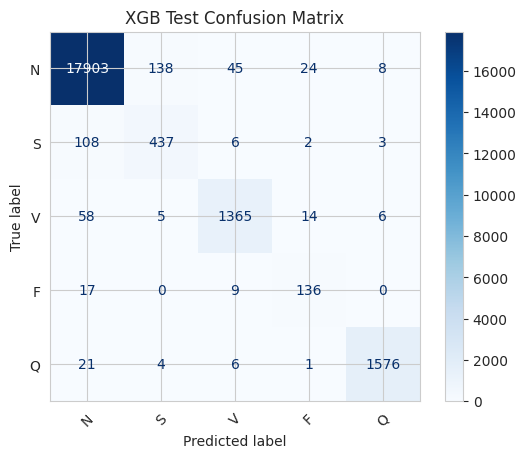

In [ ]:
# ── 5A. XGB WITH SMOTE ─────────────────────────────────────────────────────────
xgb_sm = XGBClassifier(
    objective='multi:softprob',
    num_class=len(class_names),
    eval_metric='mlogloss',
    n_estimators=200,
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)
xgb_sm.fit(X_tr_sm, y_tr_sm)

# Validation
y_val_pred_sm = xgb_sm.predict(X_val_sm)
print("=== XGB WITH SMOTE: Validation ===")
print(classification_report(
    y_val_sm, y_val_pred_sm,
    target_names=list(class_names.values()),
    zero_division=0
))

# Test
y_test_pred_sm = xgb_sm.predict(X_test_scl)
print("=== XGB WITH SMOTE: Test ===")
print(classification_report(
    y_test, y_test_pred_sm,
    target_names=list(class_names.values()),
    zero_division=0
))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_sm,
    display_labels=list(class_names.values()),
    cmap='Blues'
)
plt.title("XGB WITH SMOTE – Test Confusion Matrix")
plt.show()



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:24:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== XGB WITHOUT SMOTE: Validation ===
              precision    recall  f1-score   support

           N       0.99      1.00      0.99      7248
           S       0.93      0.70      0.80       222
           V       0.96      0.95      0.95       579
           F       0.90      0.72      0.80        64
           Q       0.99      0.98      0.99       643

    accuracy                           0.98      8756
   macro avg       0.95      0.87      0.91      8756
weighted avg       0.98      0.98      0.98      8756

=== XGB WITHOUT SMOTE: Test ===
              precision    recall  f1-score   support

           N       0.98      1.00      0.99     18118
           S       0.96      0.67      0.79       556
           V       0.98      0.93      0.95      1448
           F       0.88      0.73      0.80       162
           Q       0.99      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.96      0.86      0.90     21892
weighte

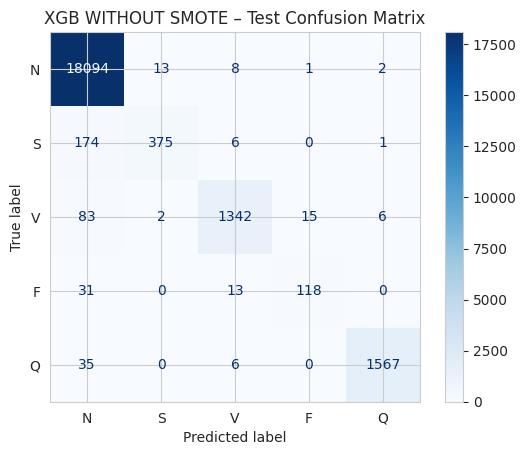

In [ ]:
# ── 5B. XGB WITHOUT SMOTE ──────────────────────────────────────────────────────
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(class_names),
    eval_metric='mlogloss',
    n_estimators=200,
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)
xgb.fit(X_tr, y_tr)

# Validation
y_val_pred = xgb.predict(X_val)
print("=== XGB WITHOUT SMOTE: Validation ===")
print(classification_report(
    y_val, y_val_pred,
    target_names=list(class_names.values()),
    zero_division=0
))

# Test
y_test_pred = xgb.predict(X_test_scl)
print("=== XGB WITHOUT SMOTE: Test ===")
print(classification_report(
    y_test, y_test_pred,
    target_names=list(class_names.values()),
    zero_division=0
))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=list(class_names.values()),
    cmap='Blues'
)
plt.title("XGB WITHOUT SMOTE – Test Confusion Matrix")
plt.show()

## 6. Deep-Learning Model – 1-D CNN

In [ ]:
# reshape for Conv1D: (samples, timesteps, channels)
X_tr_cnn   = X_tr[...,   np.newaxis]
X_val_cnn  = X_val[...,  np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

n_classes = len(class_names)  # should be 5

def build_model():
    m = models.Sequential([
        layers.Input(shape=(187,1)),
        layers.Conv1D(32, 5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool1D(2),
        layers.Dropout(0.2),
        layers.Conv1D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

model = build_model()
model.summary()


NameError: name 'X_tr' is not defined

In [ ]:
es = callbacks.EarlyStopping(patience=8, restore_best_weights=True)

with tf.device('/GPU:0'):   # optional—TF auto-uses GPU if available
    hist = model.fit(
        X_tr_cnn, y_tr,
        epochs=60,
        batch_size=512,
        validation_data=(X_val_cnn, y_val),
        callbacks=[es],
        verbose=2
    )

In [ ]:
pd.DataFrame(hist.history)[['loss','val_loss']].plot(figsize=(6,4),title='Loss'); plt.show()
pd.DataFrame(hist.history)[['accuracy','val_accuracy']].plot(figsize=(6,4),title='Accuracy'); plt.show()


## 7. Evaluation on Hold-out Test Set


Test classification report
              precision    recall  f1-score   support

           N     0.9875    0.9920    0.9897     18118
           S     0.8532    0.7212    0.7817       556
           V     0.9245    0.9641    0.9439      1448
           F     0.9098    0.6852    0.7817       162
           Q     0.9924    0.9807    0.9865      1608

    accuracy                         0.9802     21892
   macro avg     0.9335    0.8686    0.8967     21892
weighted avg     0.9797    0.9802    0.9796     21892



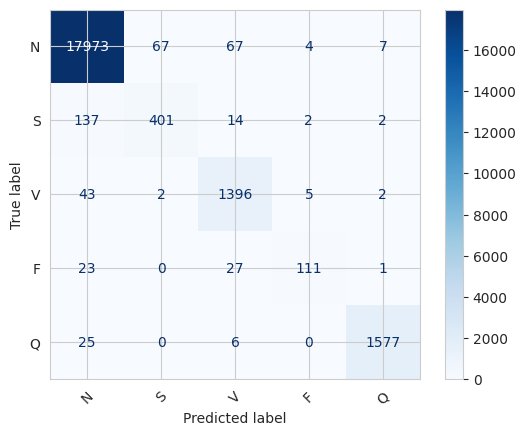

In [ ]:
test_pred = model.predict(X_test_cnn, verbose=0).argmax(axis=1)

print("\nTest classification report")
print(classification_report(y_test, test_pred,
                            target_names=class_names.values(), digits=4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names.values()).plot(
    xticks_rotation=45,cmap='Blues'); plt.show()


## 6B. CNN with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection     import train_test_split
from sklearn.preprocessing       import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# ── 1) Preprocessing with SMOTE ────────────────────────────────────────────────

# (A) Assume X_train, y_train, X_test, y_test already loaded & numeric
#     e.g. from steps above:
#     X_train = train_df.iloc[:,:187].values
#     y_train = train_df[187].astype(int).values
#     X_test  = test_df.iloc[:,:187].values
#     y_test  = test_df[187].astype(int).values

# (B) Scale features
scaler     = StandardScaler()
X_train_scl = scaler.fit_transform(X_train)
X_test_scl  = scaler.transform(X_test)

# (C) SMOTE on the **training** set only
sm          = SMOTE(random_state=SEED)
X_bal, y_bal = sm.fit_resample(X_train_scl, y_train)
print("After SMOTE:", np.bincount(y_bal))    # should be roughly equal counts for [0..4]

# (D) Train/val split **on the balanced data**
X_tr, X_val, y_tr, y_val = train_test_split(
    X_bal, y_bal,
    test_size=0.1,
    stratify=y_bal,
    random_state=SEED
)

# (E) Prepare test set (unchanged)
X_test_final = X_test_scl
y_test_final = y_test

# ── 2) Reshape for CNN ─────────────────────────────────────────────────────────
X_tr_cnn   = X_tr[...,   np.newaxis]   # (n_tr, 187, 1)
X_val_cnn  = X_val[...,  np.newaxis]   # (n_val, 187, 1)
X_test_cnn = X_test_final[..., np.newaxis]  # (n_test,187,1)

# ── 3) Build & Train the CNN ───────────────────────────────────────────────────
n_classes = len(class_names)  # =5

def build_cnn():
    m = models.Sequential([
        layers.Input((187,1)),
        layers.Conv1D(32,5,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(64,5,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool1D(2), layers.Dropout(0.2),
        layers.Conv1D(128,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128,activation='relu'), layers.Dropout(0.3),
        layers.Dense(n_classes,activation='softmax')
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

model = build_cnn()
model.summary()

After SMOTE: [72471 72471 72471 72471 72471]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 187, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,253 (208.02 KB)

 Trainable params: 52,805 (206.27 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/60
637/637 - 27s - 43ms/step - accuracy: 0.8582 - loss: 0.3908 - val_accuracy: 0.7555 - val_loss: 0.7210
Epoch 2/60
637/637 - 7s - 11ms/step - accuracy: 0.9444 - loss: 0.1624 - val_accuracy: 0.9601 - val_loss: 0.1192
Epoch 3/60
637/637 - 7s - 11ms/step - accuracy: 0.9592 - loss: 0.1190 - val_accuracy: 0.9597 - val_loss: 0.1142
Epoch 4/60
637/637 - 7s - 11ms/step - accuracy: 0.9666 - loss: 0.0977 - val_accuracy: 0.9607 - val_loss: 0.1101
Epoch 5/60
637/637 - 11s - 18ms/step - accuracy: 0.9709 - loss: 0.0847 - val_accuracy: 0.9750 - val_loss: 0.0735
Epoch 6/60
637/637 - 7s - 12ms/step - accuracy: 0.9743 - loss: 0.0750 - val_accuracy: 0.9744 - val_loss: 0.0724
Epoch 7/60
637/637 - 7s - 11ms/step - accuracy: 0.9769 - loss: 0.0679 - val_accuracy: 0.9794 - val_loss: 0.0623
Epoch 8/60
637/637 - 10s - 16ms/step - accuracy: 0.9783 - loss: 0.0632 - val_accuracy: 0.9812 - val_loss: 0.0557
Epoch 9/60
637/637 - 10s - 16ms/step - accuracy: 0.9801 - loss: 0.0579 - val_accuracy: 0.9840 - val_l

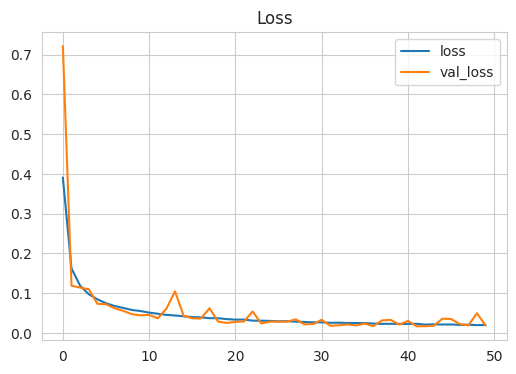

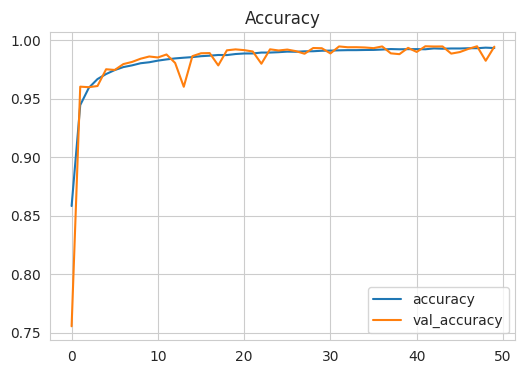

In [ ]:
es = callbacks.EarlyStopping(patience=8, restore_best_weights=True)

with tf.device('/GPU:0'):
    hist = model.fit(
        X_tr_cnn, y_tr,
        validation_data=(X_val_cnn, y_val),
        epochs=60,
        batch_size=512,
        callbacks=[es],
        verbose=2
    )

# ── 4) Learning Curves ─────────────────────────────────────────────────────────
pd.DataFrame(hist.history)[['loss','val_loss']].plot(title='Loss', figsize=(6,4))
plt.show()
pd.DataFrame(hist.history)[['accuracy','val_accuracy']].plot(title='Accuracy', figsize=(6,4))
plt.show()

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
=== CNN w/ SMOTE Test Report ===
              precision    recall  f1-score   support

           N     0.9944    0.9778    0.9860     18118
           S     0.6487    0.8669    0.7421       556
           V     0.9212    0.9682    0.9441      1448
           F     0.6980    0.8704    0.7747       162
           Q     0.9888    0.9907    0.9897      1608

    accuracy                         0.9745     21892
   macro avg     0.8502    0.9348    0.8873     21892
weighted avg     0.9782    0.9745    0.9758     21892



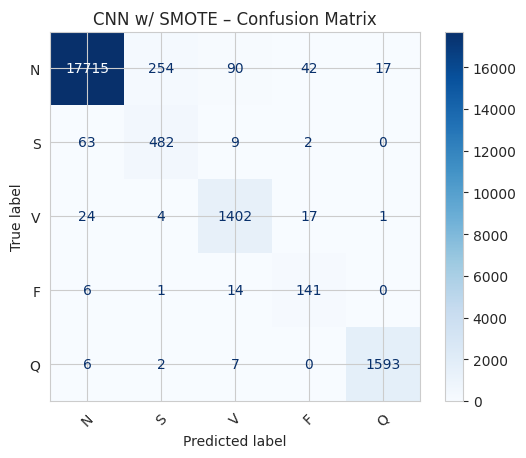

In [ ]:
# ── 5) Final Test Evaluation ───────────────────────────────────────────────────
import sklearn.metrics as m

y_pred = model.predict(X_test_cnn).argmax(axis=1)
print("=== CNN w/ SMOTE Test Report ===")
print(m.classification_report(y_test_final, y_pred,
                              target_names=list(class_names.values()),
                              digits=4))

cm = m.confusion_matrix(y_test_final, y_pred)
m.ConfusionMatrixDisplay(cm, display_labels=list(class_names.values()))\
    .plot(cmap='Blues', xticks_rotation=45)
plt.title("CNN w/ SMOTE – Confusion Matrix")
plt.show()

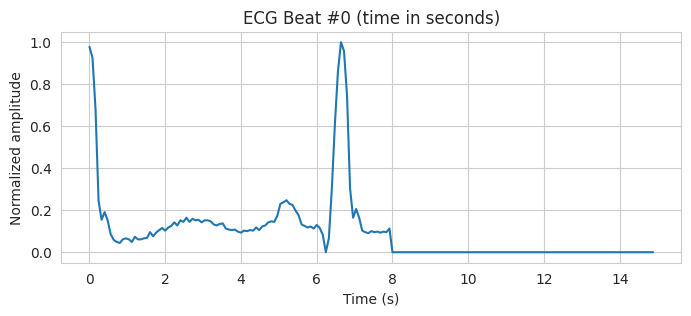

In [ ]:
# 2. Create Time-Indexed DataFrames for EDA
fs = 125                             # 125 Hz sampling
dt = 10.0 / fs                        # seconds per sample
time_idx = np.arange(187) * dt      # array([0.00, 0.008, …, 1.488])

X_train_raw = train_df.iloc[:, :187].values
X_test_raw  = test_df.iloc[:,  :187].values

X_train_df = pd.DataFrame(
    X_train_raw,
    columns=pd.Index(time_idx, name='time_s')
)
X_test_df = pd.DataFrame(
    X_test_raw,
    columns=pd.Index(time_idx, name='time_s')
)

# Example plot for beat #0
plt.figure(figsize=(8,3))
X_train_df.iloc[0].plot()
plt.title("ECG Beat #0 (time in seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.show()


# 3. Extract Arrays & Labels
label_col = 187
y_train = train_df[label_col].astype(int).values
y_test  = test_df[label_col].astype(int).values

# Convert back to numpy arrays for modeling
X_train = X_train_df.values
X_test  = X_test_df.values


# 4. Train/Validation Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1, stratify=y_train, random_state=SEED
)


# 5. Feature Scaling
scaler    = StandardScaler()
X_tr_scl  = scaler.fit_transform(X_tr)
X_val_scl = scaler.transform(X_val)
X_test_scl= scaler.transform(X_test)


# 6. Prepare for ViT: reshape to (n_samples, seq_len, 1)
X_tr_vit   = X_tr_scl[..., np.newaxis]
X_val_vit  = X_val_scl[..., np.newaxis]
X_test_vit = X_test_scl[..., np.newaxis]

In [ ]:
# 7. Build the ViT Model
def build_vit_model(
    seq_len=187, patch_size=16,
    projection_dim=64, transformer_layers=4,
    num_heads=4, transformer_units=[128],
    mlp_head_units=[128], num_classes=5
):
    num_patches = int(np.ceil(seq_len / patch_size))
    inputs = layers.Input(shape=(seq_len,1))

    # Patch extraction + projection
    x = layers.Conv1D(projection_dim, kernel_size=patch_size,
                      strides=patch_size, padding='same')(inputs)

    # Positional encoding
    pos = np.arange(num_patches)[:,None] * (1/10000)**((2*(np.arange(projection_dim)//2))/projection_dim)
    pe  = np.zeros((num_patches, projection_dim))
    pe[:,0::2] = np.sin(pos[:,0::2])
    pe[:,1::2] = np.cos(pos[:,1::2])
    x = x + tf.constant(pe, dtype=tf.float32)

    # Transformer blocks
    for _ in range(transformer_layers):
        # MHA block
        y = layers.LayerNormalization(epsilon=1e-6)(x)
        y = layers.MultiHeadAttention(num_heads=num_heads,
                                      key_dim=projection_dim)(y, y)
        y = layers.Dropout(0.1)(y)
        x = layers.Add()([x, y])
        # Feed-forward block
        y = layers.LayerNormalization(epsilon=1e-6)(x)
        for u in transformer_units:
            y = layers.Dense(u, activation='relu')(y)
        y = layers.Dense(projection_dim)(y)
        y = layers.Dropout(0.1)(y)
        x = layers.Add()([x, y])

    # Classification head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    for u in mlp_head_units:
        x = layers.Dense(u, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

vit = build_vit_model()
vit.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 12, 64)    │      1,088 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 12, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 12, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 12, 64)    │          0 │ add_4[0][0],      │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 12, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 12, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 12, 64)    │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 12, 64)    │          0 │ add_5[0][0],      │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 12, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 12, 64)    │          0 │ add_6[0][0],      │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 12, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 342,981 (1.31 MB)

 Trainable params: 342,981 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. Train ViT
es = callbacks.EarlyStopping(patience=10, restore_best_weights=True)

hist = vit.fit(
    X_tr_vit, y_tr,
    validation_data=(X_val_vit, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[es],
    verbose=2
)

Epoch 1/50
308/308 - 50s - 161ms/step - accuracy: 0.8780 - loss: 0.4555 - val_accuracy: 0.9340 - val_loss: 0.2808
Epoch 2/50
308/308 - 4s - 15ms/step - accuracy: 0.9342 - loss: 0.2590 - val_accuracy: 0.9455 - val_loss: 0.2065
Epoch 3/50
308/308 - 4s - 14ms/step - accuracy: 0.9475 - loss: 0.2047 - val_accuracy: 0.9531 - val_loss: 0.1715
Epoch 4/50
308/308 - 4s - 14ms/step - accuracy: 0.9529 - loss: 0.1795 - val_accuracy: 0.9564 - val_loss: 0.1506
Epoch 5/50
308/308 - 5s - 17ms/step - accuracy: 0.9563 - loss: 0.1629 - val_accuracy: 0.9607 - val_loss: 0.1369
Epoch 6/50
308/308 - 5s - 16ms/step - accuracy: 0.9596 - loss: 0.1471 - val_accuracy: 0.9639 - val_loss: 0.1238
Epoch 7/50
308/308 - 5s - 16ms/step - accuracy: 0.9624 - loss: 0.1357 - val_accuracy: 0.9678 - val_loss: 0.1146
Epoch 8/50
308/308 - 5s - 15ms/step - accuracy: 0.9650 - loss: 0.1273 - val_accuracy: 0.9692 - val_loss: 0.1066
Epoch 9/50
308/308 - 5s - 16ms/step - accuracy: 0.9671 - loss: 0.1195 - val_accuracy: 0.9729 - val_los

<Figure size 600x400 with 0 Axes>

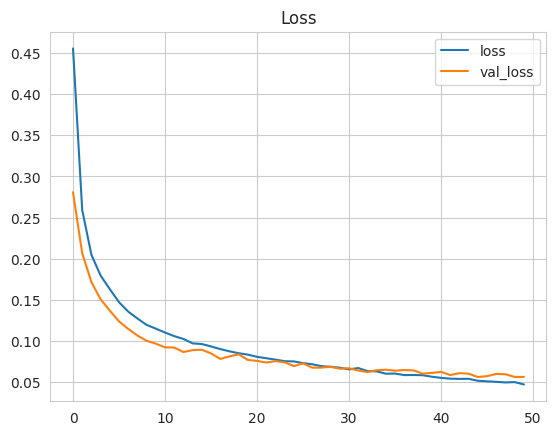

<Figure size 600x400 with 0 Axes>

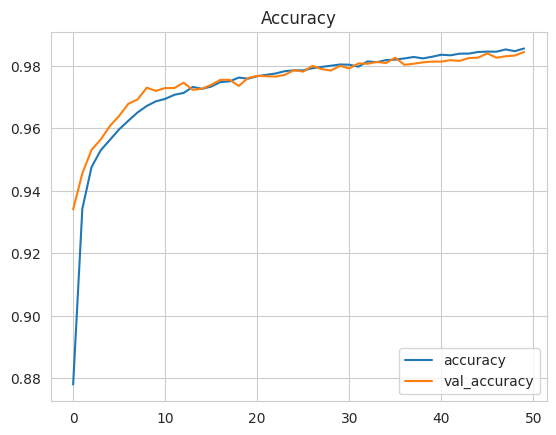

In [ ]:
# Plot learning curves
plt.figure(figsize=(6,4))
pd.DataFrame(hist.history)[['loss','val_loss']].plot(title='Loss'); plt.show()
plt.figure(figsize=(6,4))
pd.DataFrame(hist.history)[['accuracy','val_accuracy']].plot(title='Accuracy'); plt.show()

685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
=== ViT Test Report ===
              precision    recall  f1-score   support

           N     0.9877    0.9918    0.9897     18118
           S     0.8493    0.7194    0.7790       556
           V     0.9374    0.9517    0.9445      1448
           F     0.8153    0.7901    0.8025       162
           Q     0.9900    0.9857    0.9878      1608

    accuracy                         0.9803     21892
   macro avg     0.9159    0.8877    0.9007     21892
weighted avg     0.9797    0.9803    0.9799     21892



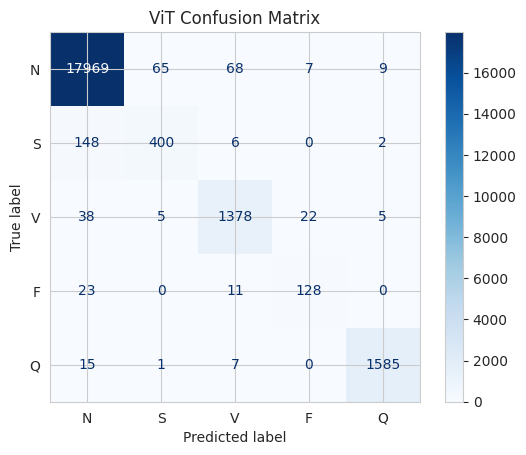

In [ ]:
# 9. Evaluate on Test Set
y_pred = vit.predict(X_test_vit).argmax(axis=1)
print("=== ViT Test Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=list(class_names.values()),
    digits=4
))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(class_names.values()),
    cmap='Blues'
)
plt.title("ViT Confusion Matrix")
plt.show()

In [ ]:
# split X/y
X = train_df.iloc[:,:187].values
y = train_df[187].astype(int).values
X_test = test_df.iloc[:,:187].values
y_test = test_df[187].astype(int).values

# train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=SEED)

# scale
scaler     = StandardScaler()
X_tr_scl   = scaler.fit_transform(X_tr)
X_val_scl  = scaler.transform(X_val)
X_test_scl = scaler.transform(X_test)

# reshape for ViT: (n, seq_len, 1)
X_tr_vit   = X_tr_scl[..., np.newaxis]
X_val_vit  = X_val_scl[..., np.newaxis]
X_test_vit = X_test_scl[..., np.newaxis]


# ── 2. Build Enhanced ViT ───────────────────────────────────────────────────────
def make_focal_loss(gamma=2.0, alpha=0.25, n_classes=5):
    alpha = tf.constant([alpha]*n_classes, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true,tf.int32), n_classes)
        p = tf.clip_by_value(y_pred,1e-7,1.-1e-7)
        ce = -y_true_oh * tf.math.log(p)
        p_t = tf.reduce_sum(y_true_oh * p, axis=-1, keepdims=True)
        weight = tf.pow(1. - p_t, gamma)
        alpha_t = tf.reduce_sum(y_true_oh * alpha, axis=-1, keepdims=True)
        return tf.reduce_mean(alpha_t * weight * ce)
    return loss

class PatchExtractor(layers.Layer):
    def __init__(self, patch_size, **kw):
        super().__init__(**kw); self.patch_size=patch_size
    def call(self, x):
        bs, L, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]
        n_p = tf.cast(tf.math.ceil(L/self.patch_size),tf.int32)
        pad = n_p*self.patch_size - L
        x = tf.pad(x,[[0,0],[0,pad],[0,0]])
        return tf.reshape(x, [bs, n_p, self.patch_size*C])

def build_vit(
    seq_len=187, patch_size=16,
    proj_dim=128, n_heads=8, n_layers=6,
    mlp_units=[256], num_classes=5
):
    # positional table
    n_patches = int(np.ceil(seq_len/patch_size))
    pos = np.arange(n_patches)[:,None] * (1/10000)**((2*(np.arange(proj_dim)//2))/proj_dim)
    pe  = np.zeros((n_patches,proj_dim))
    pe[:,0::2] = np.sin(pos[:,0::2]); pe[:,1::2] = np.cos(pos[:,1::2])
    pe  = tf.constant(pe, dtype=tf.float32)

    inp = layers.Input((seq_len,1))
    # patch + projection
    x = PatchExtractor(patch_size)(inp)
    x = layers.Dense(proj_dim)(x)
    x = x + pe

    # transformer stack
    for _ in range(n_layers):
        # MHA
        y = layers.LayerNormalization(epsilon=1e-6)(x)
        y = layers.MultiHeadAttention(n_heads, key_dim=proj_dim)(y,y)
        y = layers.Dropout(0.1)(y)
        x = layers.Add()([x,y])
        # FFN
        y = layers.LayerNormalization(epsilon=1e-6)(x)
        y = layers.Dense(proj_dim*2, activation='relu')(y)
        y = layers.Dense(proj_dim)(y)
        y = layers.Dropout(0.1)(y)
        x = layers.Add()([x,y])

    # head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    for u in mlp_units:
        x = layers.Dense(u, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    m = models.Model(inp,out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=make_focal_loss(gamma=2.,alpha=0.25,n_classes=num_classes),
        metrics=['accuracy']
    )
    return m

vit = build_vit()
vit.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 12, 16)    │          0 │ input_layer_4[0]… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 12, 128)   │      2,176 │ patch_extractor[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 12, 128)   │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │    527,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 12, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 12, 128)   │          0 │ add_13[0][0],     │
│                     │                   │            │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 12, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 12, 128)   │     32,896 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 12, 128)   │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 12, 128)   │          0 │ add_14[0][0],     │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │    527,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 12, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 12, 128)   │          0 │ add_15[0][0],     │
│                     │                   │            │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 3,600,261 (13.73 MB)

 Trainable params: 3,600,261 (13.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 256
train_ds = tf.data.Dataset.from_tensor_slices((X_tr_vit,y_tr))
train_ds = (train_ds
            .shuffle(5000, seed=SEED)
            .batch(batch_size)
            .prefetch(2))
val_ds = tf.data.Dataset.from_tensor_slices((X_val_vit,y_val))\
             .batch(batch_size).prefetch(2)


In [ ]:
from sklearn.utils               import class_weight
# ── 4. Compute Class Weights ─────────────────────────────────────────────────────
cw = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = {i: w for i,w in enumerate(cw)}

Epoch 1/80
308/308 - 79s - 257ms/step - accuracy: 0.8902 - loss: 0.0097 - val_accuracy: 0.9340 - val_loss: 0.0049
Epoch 2/80
308/308 - 45s - 145ms/step - accuracy: 0.9469 - loss: 0.0043 - val_accuracy: 0.9582 - val_loss: 0.0031
Epoch 3/80
308/308 - 24s - 79ms/step - accuracy: 0.9574 - loss: 0.0032 - val_accuracy: 0.9638 - val_loss: 0.0024
Epoch 4/80
308/308 - 40s - 131ms/step - accuracy: 0.9634 - loss: 0.0028 - val_accuracy: 0.9681 - val_loss: 0.0021
Epoch 5/80
308/308 - 41s - 134ms/step - accuracy: 0.9656 - loss: 0.0025 - val_accuracy: 0.9698 - val_loss: 0.0020
Epoch 6/80
308/308 - 41s - 132ms/step - accuracy: 0.9695 - loss: 0.0022 - val_accuracy: 0.9743 - val_loss: 0.0017
Epoch 7/80
308/308 - 24s - 77ms/step - accuracy: 0.9718 - loss: 0.0020 - val_accuracy: 0.9728 - val_loss: 0.0018
Epoch 8/80
308/308 - 23s - 76ms/step - accuracy: 0.9730 - loss: 0.0019 - val_accuracy: 0.9754 - val_loss: 0.0016
Epoch 9/80
308/308 - 41s - 133ms/step - accuracy: 0.9741 - loss: 0.0017 - val_accuracy: 0.9

<Figure size 600x400 with 0 Axes>

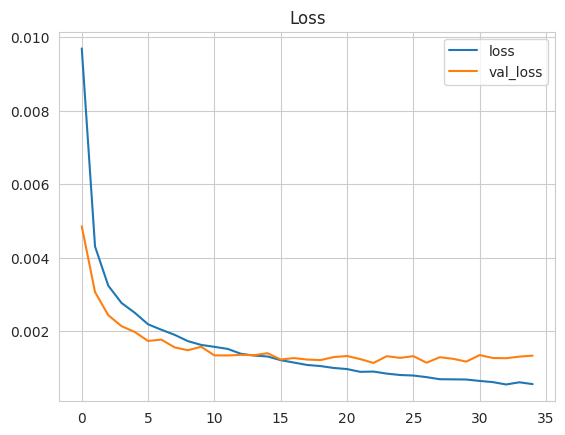

<Figure size 600x400 with 0 Axes>

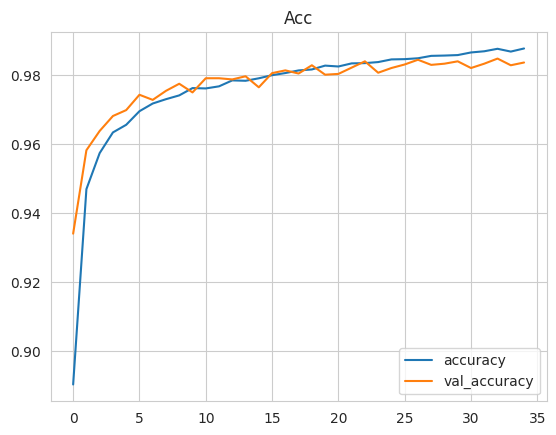

In [ ]:
# ── 5. Train ─────────────────────────────────────────────────────────────────────
es = callbacks.EarlyStopping(patience=12, restore_best_weights=True)
hist = vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weights,
    callbacks=[es],
    verbose=2
)

# learning curves
plt.figure(figsize=(6,4))
pd.DataFrame(hist.history)[['loss','val_loss']].plot(title='Loss'); plt.show()
plt.figure(figsize=(6,4))
pd.DataFrame(hist.history)[['accuracy','val_accuracy']].plot(title='Acc'); plt.show()

86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step
=== Improved ViT Test Report ===
              precision    recall  f1-score   support

           N     0.9845    0.9939    0.9892     18118
           S     0.9031    0.6871    0.7804       556
           V     0.9346    0.9468    0.9407      1448
           F     0.8472    0.7531    0.7974       162
           Q     0.9904    0.9658    0.9780      1608

    accuracy                         0.9791     21892
   macro avg     0.9320    0.8693    0.8971     21892
weighted avg     0.9786    0.9791    0.9784     21892



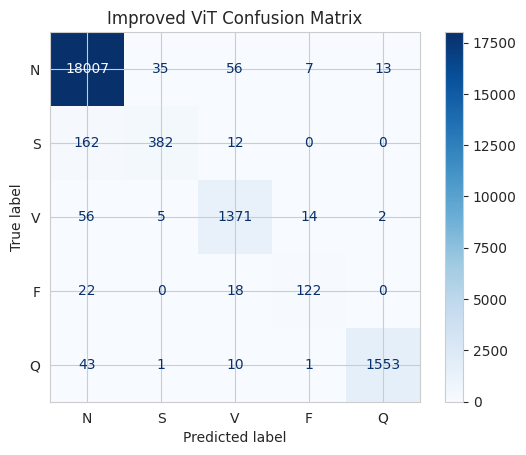

In [ ]:
# ── 6. Evaluate ─────────────────────────────────────────────────────────────────
y_pred = vit.predict(X_test_vit, batch_size=batch_size).argmax(axis=1)
print("=== Improved ViT Test Report ===")
print(classification_report(y_test, y_pred,
                            target_names=list(class_names.values()), digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(class_names.values()), cmap='Blues'
)
plt.title("Improved ViT Confusion Matrix")
plt.show()

## Second try Hybrid CNN + Transformer

In [ ]:
# ────────────────────────────────────────────────────────────────────────────────
# Part E: Model Building, Training & Evaluation for MIT-BIH
# ────────────────────────────────────────────────────────────────────────────────

# 0) Mount Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# 1) Environment & Installs
!pip -q install imbalanced-learn==0.12 seaborn==0.13 tf-keras-vis==0.8 pywavelets

# 2) Imports
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import classification_report, confusion_matrix
from imblearn.over_sampling   import SMOTE
from tensorflow.keras.callbacks import ModelCheckpoint, Callback
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    GlobalAveragePooling1D, Dense, Dropout, Flatten,
    MultiHeadAttention, LayerNormalization, Add
)
from tensorflow.keras.models  import Model


Mounted at /content/drive
ERROR: Ignored the following versions that require a different python version: 0.2.0 Requires-Python >=3.5, <3.8; 0.2.1 Requires-Python >=3.5, <3.8; 0.2.3 Requires-Python >=3.5, <3.8; 0.2.4 Requires-Python >=3.5, <=3.8; 0.2.5 Requires-Python >=3.5, <3.9; 0.3.1 Requires-Python >=3.5, <3.9; 0.3.2 Requires-Python >=3.5, <3.9; 0.3.3 Requires-Python >=3.5, <3.9; 0.4.0 Requires-Python >=3.5, <3.9; 0.5.0 Requires-Python >=3.5, <3.9; 0.5.2 Requires-Python >=3.5, <3.9; 0.5.3 Requires-Python >=3.5, <3.9; 0.5.4 Requires-Python >=3.5, <3.9; 0.5.5 Requires-Python >=3.6, <3.9; 0.6.0 Requires-Python >=3.6, <3.10; 0.6.1 Requires-Python >=3.6, <3.10; 0.6.2 Requires-Python >=3.6, <3.10; 0.7.0 Requires-Python >=3.6, <3.10; 0.7.1 Requires-Python >=3.6, <3.10; 0.7.2 Requires-Python >=3.6, <3.10; 0.8.0 Requires-Python >=3.6, <3.10; 0.8.1 Requires-Python >=3.7, <3.11
ERROR: Could not find a version that satisfies the requirement tf-keras-vis==0.8 (from versions: 0.0.1, 0.1.0, 0.8.2,

In [ ]:
# 3) Paths & Constants
BASE_PATH   = '/content/drive/MyDrive'
TRAIN_PATH  = f'{BASE_PATH}/mitbih_train.csv'
TEST_PATH   = f'{BASE_PATH}/mitbih_test.csv'
LOG_DIR     = f'{BASE_PATH}/logs'
os.makedirs(LOG_DIR, exist_ok=True)

In [ ]:
LABEL_COL   = 187
CLASS_MAP   = {0:"N", 1:"S", 2:"V", 3:"F", 4:"Q"}
COLORS      = sns.color_palette("tab10", n_colors=5)

# 4) Load & Prep
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)

# ensure integer labels
train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
test_df[ LABEL_COL] = test_df[ LABEL_COL].astype(int)

X_train = train_df.iloc[:, :LABEL_COL].values
y_train = train_df.iloc[:, LABEL_COL].values
X_test  = test_df .iloc[:, :LABEL_COL].values
y_test  = test_df .iloc[:, LABEL_COL].values

scaler       = StandardScaler()
X_train_scl  = scaler.fit_transform(X_train)
X_test_scl   = scaler.transform(X_test)

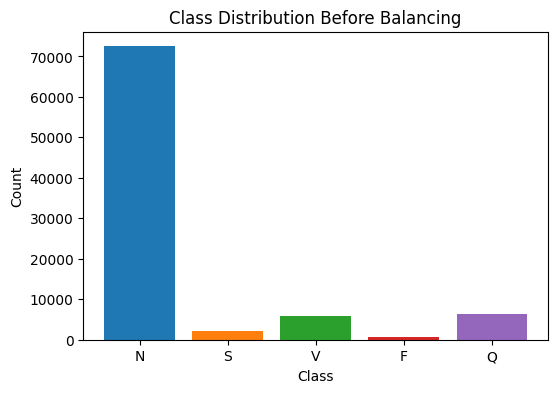

In [ ]:
# 5) EDA: Before Balancing
counts = pd.Series(y_train).value_counts().sort_index()
plt.figure(figsize=(6,4))
bars = plt.bar(
    [CLASS_MAP[i] for i in counts.index],
    counts.values,
    color=[COLORS[i] for i in counts.index]
)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# 6) SMOTE-Tomek + Undersample to 50K ea.
# split out class 0
arr = np.hstack((X_train_scl, y_train.reshape(-1,1)))
df0    = arr[arr[:,-1]==0]
df1234 = arr[arr[:,-1]!=0]

# 6.1) Undersample N (0) to 50k
df0_res = pd.DataFrame(df0).sample(n=50000, random_state=42).to_numpy()

# 6.2) SMOTE classes 1–4 up to 50k each
X_4cl, y_4cl = df1234[:,:-1], df1234[:,-1]
sm = SMOTE(sampling_strategy={1:50000,2:50000,3:50000,4:50000}, random_state=42)
X_s, y_s     = sm.fit_resample(X_4cl, y_4cl)
df1234_res   = np.hstack((X_s, y_s.reshape(-1,1)))

# 6.3) Combine & shuffle
train_bal = np.vstack((df0_res, df1234_res))
np.random.shuffle(train_bal)

X_tr = train_bal[:,:LABEL_COL].reshape(-1, LABEL_COL, 1)
y_tr = train_bal[:, LABEL_COL].astype(int)
X_te = X_test_scl.reshape(-1, LABEL_COL, 1)
y_te = y_test.astype(int)


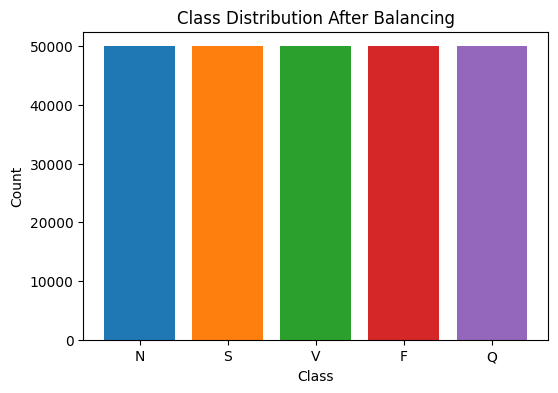

In [ ]:
# 7) EDA: After Balancing
new_counts = pd.Series(y_tr).value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(
    [CLASS_MAP[i] for i in new_counts.index],
    new_counts.values,
    color=[COLORS[i] for i in new_counts.index]
)
plt.title("Class Distribution After Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# ────────────────────────────────────────────────────────────────────────────────
# 8) Model Definition
# ────────────────────────────────────────────────────────────────────────────────

class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8):
        super().__init__()
        self.filters = filters
        self.ratio   = ratio
        self.avg_pool = tf.keras.layers.GlobalAveragePooling1D()
        self.max_pool = tf.keras.layers.GlobalMaxPooling1D()
        self.shared_one = Dense(filters//ratio, activation='relu', use_bias=True)
        self.shared_two = Dense(filters,        use_bias=True)

    def call(self, inputs):
        # avg
        x1 = self.avg_pool(inputs)
        x1 = self.shared_one(tf.expand_dims(x1,1))
        x1 = self.shared_two(x1)
        # max
        x2 = self.max_pool(inputs)
        x2 = self.shared_one(tf.expand_dims(x2,1))
        x2 = self.shared_two(x2)
        # combine
        attn = tf.nn.sigmoid(x1 + x2)
        return inputs * attn

class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.d_model   = d_model
        # multi‐head self‐attention
        self.mha       = MultiHeadAttention(key_dim=d_model, num_heads=num_heads)
        self.dropout1  = Dropout(dropout_rate)
        self.norm1     = LayerNormalization(epsilon=1e-6)
        # feed-forward: up → down
        self.ffn_up    = Dense(dff, activation='relu')
        self.ffn_down  = Dense(d_model)
        self.dropout2  = Dropout(dropout_rate)
        self.norm2     = LayerNormalization(epsilon=1e-6)

    def call(self, x, training=False):
        # --- self‐attention branch ---
        attn_out = self.mha(x, x)
        attn_out = self.dropout1(attn_out, training=training)
        out1     = self.norm1(x + attn_out)

        # --- feed-forward branch ---
        ffn      = self.ffn_up(out1)          # [B, T, dff]
        ffn      = self.ffn_down(ffn)         # [B, T, d_model]
        ffn      = self.dropout2(ffn, training=training)
        return self.norm2(out1 + ffn)


def build_model(seq_len=187, channels=1,
                d_model=64, num_heads=4, dff=128, drop_rate=0.2):
    inp = Input(shape=(seq_len, channels))
    # --- CNN block ---
    x = Conv1D(16, 21, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = ChannelAttention(16)(x)
    x = MaxPooling1D(3, 2, padding='same')(x)

    x = Conv1D(32, 23, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = ChannelAttention(32)(x)
    x = MaxPooling1D(3, 2, padding='same')(x)

    x = Conv1D(64, 25, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = ChannelAttention(64)(x)
    # Project channels to d_model for Transformer
    x = Dense(d_model)(x)

    # --- Transformer Encoder ---
    x = TransformerEncoder(num_heads, d_model, dff, drop_rate)(x)

    # --- Head ---
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(drop_rate)(x)
    out = Dense(len(CLASS_MAP), activation='softmax')(x)

    return Model(inputs=inp, outputs=out)

In [ ]:
# 9) Timing Callback & Checkpoint
class EpochTimer(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()
    def on_epoch_end(self, epoch, logs=None):
        dur = time.time() - self.start_time
        print(f"→ Epoch {epoch+1} duration: {dur:.1f}s")

checkpoint_filepath = f"{LOG_DIR}/cnn_transformer_mitbih_smotetomek_best.h5"
ckpt_cb = ModelCheckpoint(
    checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
timer_cb = EpochTimer()

In [ ]:
# 10) Compile & Train
model = build_model(seq_len=LABEL_COL, channels=1)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_tr, y_tr,
    validation_split=0.1,
    epochs=60,
    batch_size=256,
    callbacks=[ckpt_cb, timer_cb]
)

Epoch 1/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9139 - loss: 0.2569
Epoch 1: val_loss improved from inf to 0.05597, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 1 duration: 43.7s
879/879 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9140 - loss: 0.2568 - val_accuracy: 0.9814 - val_loss: 0.0560
Epoch 2/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9806 - loss: 0.0558
Epoch 2: val_loss improved from 0.05597 to 0.03093, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 2 duration: 14.5s
879/879 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9806 - loss: 0.0558 - val_accuracy: 0.9898 - val_loss: 0.0309
Epoch 3/60
877/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9882 - loss: 0.0351
Epoch 3: val_loss improved from 0.03093 to 0.02926, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 3 duration: 19.9s
879/879 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9882 - loss: 0.0351 - val_accuracy: 0.9904 - val_loss: 0.0293
Epoch 4/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9903 - loss: 0.0286
Epoch 4: val_loss improved from 0.02926 to 0.02645, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 4 duration: 14.1s
879/879 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9903 - loss: 0.0286 - val_accuracy: 0.9918 - val_loss: 0.0265
Epoch 5/60
877/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9922 - loss: 0.0238
Epoch 5: val_loss improved from 0.02645 to 0.02490, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


...

→ Epoch 10 duration: 21.4s
879/879 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.9951 - val_loss: 0.0181
Epoch 11/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9958 - loss: 0.0123
Epoch 11: val_loss did not improve from 0.01810
→ Epoch 11 duration: 13.1s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9958 - loss: 0.0123 - val_accuracy: 0.9942 - val_loss: 0.0200
Epoch 12/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9959 - loss: 0.0128
Epoch 12: val_loss improved from 0.01810 to 0.01572, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 12 duration: 22.2s
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9954 - val_loss: 0.0157
Epoch 13/60
877/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9962 - loss: 0.0119
Epoch 13: val_loss did not improve from 0.01572
→ Epoch 13 duration: 18.9s
879/879 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9952 - val_loss: 0.0157
Epoch 14/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9967 - loss: 0.0102
Epoch 14: val_loss improved from 0.01572 to 0.01302, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 14 duration: 21.5s
879/879 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9959 - val_loss: 0.0130
Epoch 15/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9974 - loss: 0.0081
Epoch 15: val_loss did not improve from 0.01302
→ Epoch 15 duration: 13.4s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9942 - val_loss: 0.0203
Epoch 16/60
877/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9972 - loss: 0.0091
Epoch 16: val_loss did not improve from 0.01302
→ Epoch 16 duration: 13.2s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9972 - loss: 0.0091 - val_accuracy: 0.9969 - val_loss: 0.0133
Epoch 17/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9977 - loss: 0.0076
Epoch 17: val_loss did not improve from 0.01302
→ Epoch 17 duration: 13.2s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9952 - val_loss: 0.0173
Epoch 18

→ Epoch 23 duration: 14.4s
879/879 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9978 - loss: 0.0071 - val_accuracy: 0.9972 - val_loss: 0.0122
Epoch 24/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9982 - loss: 0.0055
Epoch 24: val_loss did not improve from 0.01217
→ Epoch 24 duration: 13.1s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9962 - val_loss: 0.0171
Epoch 25/60
878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9982 - loss: 0.0056
Epoch 25: val_loss improved from 0.01217 to 0.01021, saving model to /content/drive/MyDrive/logs/cnn_transformer_mitbih_smotetomek_best.h5


→ Epoch 25 duration: 21.8s
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9972 - val_loss: 0.0102
Epoch 26/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9982 - loss: 0.0055
Epoch 26: val_loss did not improve from 0.01021
→ Epoch 26 duration: 19.3s
879/879 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9963 - val_loss: 0.0148
Epoch 27/60
876/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9981 - loss: 0.0056
Epoch 27: val_loss did not improve from 0.01021
→ Epoch 27 duration: 13.3s
879/879 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9968 - val_loss: 0.0162
Epoch 28/60
878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9985 - loss: 0.0046
Epoch 28: val_loss did not improve from 0.01021
→ Epoch 28 duration: 20.5s
879/879 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9954 - val_loss: 0.0221
Epoch 29

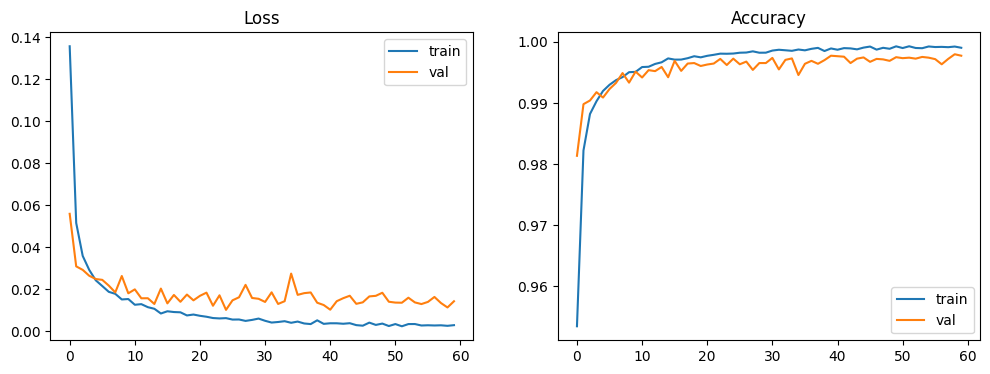

In [ ]:
# 11) Plot Training Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Classification Report:

              precision    recall  f1-score   support

           N       0.99      0.99      0.99     18118
           S       0.86      0.83      0.84       556
           V       0.97      0.95      0.96      1448
           F       0.77      0.85      0.81       162
           Q       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.92      0.92      0.92     21892
weighted avg       0.98      0.98      0.98     21892



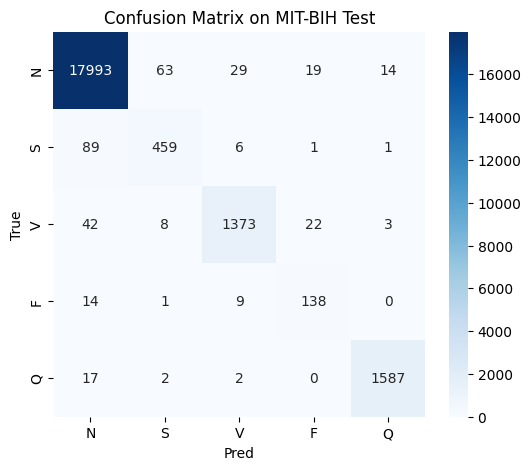

In [ ]:
# 12) Load Best & Evaluate on Test
model.load_weights(checkpoint_filepath)
y_pred = np.argmax(model.predict(X_te), axis=1)

print("Classification Report:\n")
print(classification_report(
    y_te, y_pred,
    target_names=[CLASS_MAP[i] for i in range(5)]
))

# 13) Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=[CLASS_MAP[i] for i in range(5)],
    yticklabels=[CLASS_MAP[i] for i in range(5)],
    cmap='Blues'
)
plt.ylabel('True')
plt.xlabel('Pred')
plt.title('Confusion Matrix on MIT-BIH Test')
plt.show()

## 8. Model Interpretability – Saliency Map (optional)

In [ ]:
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils  import normalize

def loss(output):
    return output[:, np.argmax(test_pred[0])]

saliency = Saliency(model, model_modifier=None, clone=True)
sample_idx = 0
sample = X_test_cnn[sample_idx:sample_idx+1]
saliency_map = saliency(loss, sample)  # shape (1,187)

plt.figure(figsize=(10,3))
plt.plot(sample.squeeze(), label='ECG')
plt.twinx().plot(normalize(saliency_map).squeeze(), 'r', alpha=0.6, label='Saliency')
plt.title(f"Grad-based saliency | true={class_names[y_test[sample_idx]]}  pred={class_names[test_pred[sample_idx]]}")
plt.legend(loc='upper right'); plt.show()
